In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.


['sample_submission.csv', 'test.csv.zip', 'train.csv.zip', 'labels.csv.zip', 'train.csv', 'new-york-city-taxi-fare-prediction', 'test.csv', 'labels.csv', 'description.md', 'GCP-Coupons-Instructions.rtf', 'sample_submission.csv.zip']


In [2]:
data =  pd.read_csv('../input/train.csv', nrows = 15_000_000)


In [3]:
# Given a dataframe, add two new features 'abs_diff_longitude' and
# 'abs_diff_latitude' reprensenting the "Manhattan vector" from
# the pickup location to the dropoff location.
def add_travel_vector_features(df):
    df['abs_diff_longitude'] = (df.dropoff_longitude - df.pickup_longitude).abs()
    df['abs_diff_latitude'] = (df.dropoff_latitude - df.pickup_latitude).abs()

add_travel_vector_features(data)


In [4]:
from datetime import datetime
data['datetime_object'] = [datetime.strptime(date,'%Y-%m-%d %H:%M:%S %Z') for date in data['pickup_datetime']]


In [5]:
def distance(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295 # Pi/180
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a)) # 2*R*asin...

# add new column to dataframe with distance in miles
data['distance_miles'] = distance(data.pickup_latitude, data.pickup_longitude, \
                                      data.dropoff_latitude, data.dropoff_longitude)

#data.distance_miles.hist(bins=50, figsize=(12,4))
#plt.xlabel('distance miles')
#plt.title('Histogram ride distances in miles')
data.distance_miles.describe()
data.groupby('passenger_count')['distance_miles', 'fare_amount'].mean()
print("Average $USD/Mile : {:0.2f}".format(data.fare_amount.sum()/data.distance_miles.sum()))
data['fare_per_mile'] = data.fare_amount / data.distance_miles
data['inv_distance_miles'] = 1/data.distance_miles
data['hour'] = [date.hour for date in data['datetime_object']]
data['year'] = [date.year for date in data['datetime_object']]


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in cos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arcsin
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
corrmat = data.corr()
f, ax = plt.subplots(figsize=(12, 9))

k = 14 #number of variables for heatmap
cols = corrmat.nlargest(k, 'fare_amount')['fare_amount'].index
cm = np.corrcoef(data[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()


ValueError: could not convert string to float: '2009-06-15 17:26:21.0000001'

In [7]:
print('Old size: %d' % len(data))
data = data.dropna(how = 'any', axis = 'rows')
print('New size: %d' % len(data))


Old size: 15000000
New size: 14999901


In [8]:
print('Old size: %d' % len(data))
data = data[(data.abs_diff_longitude < 3.0) & (data.abs_diff_latitude < 3.0)]
data = data[data.fare_amount>0]
data = data[data.passenger_count <=9]
data = data[(data.distance_miles>0.0)]
print('New size: %d' % len(data))


Old size: 14999901
New size: 14540309


2009-06-15 17:26:21


KeyError: 'hour'

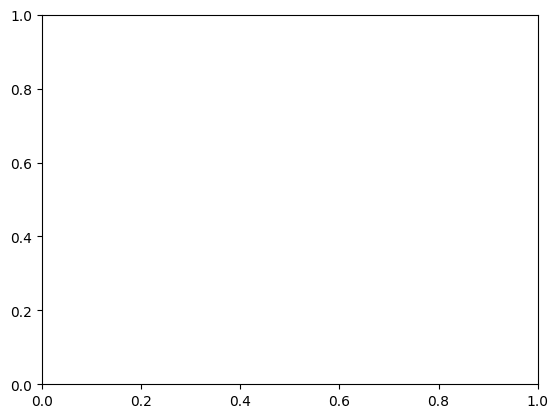

In [9]:
print(data['datetime_object'][0])

plot = data.iloc[:1000].plot.scatter('hour', 'fare_amount')


In [10]:
from sklearn.model_selection import train_test_split
y = data.fare_amount
X = data.drop('fare_amount', axis=1)
train_df, val_df, train_y, val_y = train_test_split(X, y,test_size=0.2)
train_df.dtypes


key                           object
pickup_datetime               object
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
passenger_count                int64
abs_diff_longitude           float64
abs_diff_latitude            float64
datetime_object       datetime64[ns]
distance_miles               float64
dtype: object

In [11]:
# Construct and return an Nx3 input matrix for our linear model
# using the travel vector, plus a 1.0 for a constant bias term.
def get_input_matrix(df):
    return np.column_stack((df.abs_diff_longitude, df.abs_diff_latitude, np.ones(len(df))))

train_X = get_input_matrix(train_df)
#train_y = np.array(train_df['fare_amount'])

print(train_X.shape)
print(train_y.shape)


(11632247, 3)
(11632247,)


In [12]:
# The lstsq function returns several things, and we only care about the actual weight vector w.
(w, _, _, _) = np.linalg.lstsq(train_X, train_y, rcond = None)
print(w)


[157.13628161  91.13367108   5.71085558]


In [13]:
w_OLS = np.matmul(np.matmul(np.linalg.inv(np.matmul(train_X.T, train_X)), train_X.T), train_y)
print(w_OLS)


[157.13628161  91.13367108   5.71085558]


In [14]:
test_df = pd.read_csv('../input/test.csv')
#test_df['distance_miles'] = distance(test_df.pickup_latitude, test_df.pickup_longitude, \
#                                      test_df.dropoff_latitude, test_df.dropoff_longitude)
#test_df['datetime_object'] = [datetime.strptime(date,'%Y-%m-%d %H:%M:%S %Z') for date in test_df['pickup_datetime']]
#test_df['hour'] = [date.hour for date in test_df['datetime_object']]
#test_df['year'] = [date.year for date in test_df['datetime_object']]

#val_df['distance_miles'] = distance(val_df.pickup_latitude, val_df.pickup_longitude, \
#                                      val_df.dropoff_latitude, val_df.dropoff_longitude)
#val_df['datetime_object'] = [datetime.strptime(date,'%Y-%m-%d %H:%M:%S %Z') for date in val_df['pickup_datetime']]
#val_df['hour'] = [date.hour for date in val_df['datetime_object']]
#val_df['year'] = [date.year for date in val_df['datetime_object']]
test_df.dtypes
#val_df = pd.read_csv('../input/train.csv', nrows = 10000000)
#val_df.dtypes


key                   object
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [15]:
# Reuse the above helper functions to add our features and generate the input matrix.
add_travel_vector_features(test_df)
test_X = get_input_matrix(test_df)
add_travel_vector_features(val_df)
#val_df = val_df.dropna(how = 'any', axis = 'rows')
#val_df = val_df[(val_df.abs_diff_longitude < 5.0) & (val_df.abs_diff_latitude < 5.0)]
val_X = get_input_matrix(val_df)
# Predict fare_amount on the test set using our model (w) trained on the training set.
test_y_predictions = np.matmul(test_X, w).round(decimals = 2)
val_y_predictions = np.matmul(val_X, w).round(decimals = 2)
#val_y = np.array(val_df['fare_amount'])

from sklearn.metrics import mean_squared_error
print(np.sqrt(mean_squared_error(val_y, val_y_predictions)))
# Write the predictions to a CSV file which we can submit to the competition.
submission = pd.DataFrame(
    {'key': test_df.key, 'fare_amount': test_y_predictions},
    columns = ['key', 'fare_amount'])
submission.to_csv('submission.csv', index = False)

print(os.listdir('.'))


6.106132005391756
['new-york-city-taxi-fare-prediction', 'new-york-city-taxi-fare-prediction_rishabh254_nyc-ola_v11_C1.ipynb', 'submission.csv']
